Mounted at /content/drive


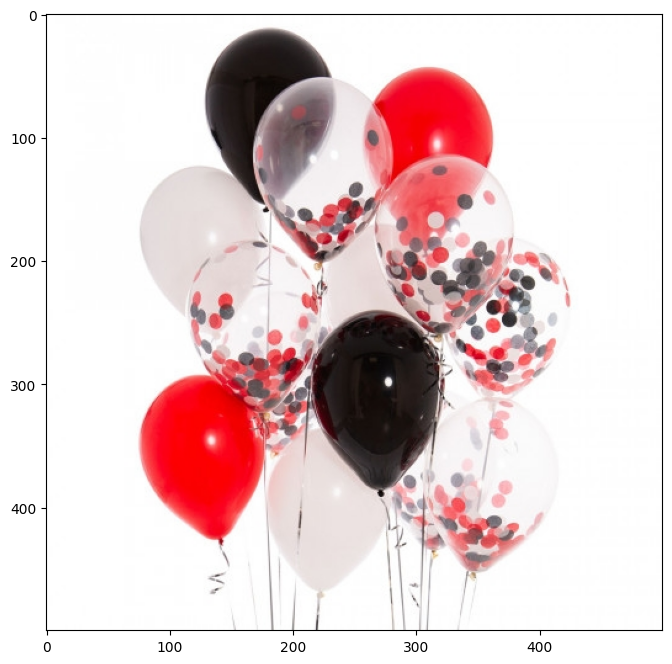

In [1]:
import sys
%matplotlib inline
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
from matplotlib import colors
from matplotlib.colors import hsv_to_rgb
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Colab_Notebooks/COI')

image = cv.imread('/content/drive/My Drive/lab5_image.jpg')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.show()

Нужно выделить шарики черного цвета

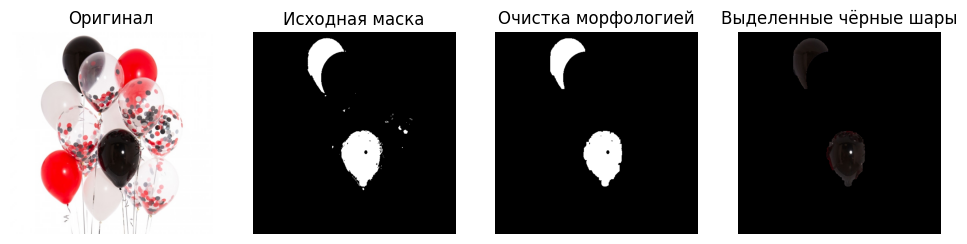

In [25]:

# Перевод в HSV
hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

# Диапазон чёрного
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 60])

mask = cv.inRange(hsv, lower_black, upper_black)

# Ядро
kernel = np.ones((7, 7), np.float32) / 49

mask_opened = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)

mask_clean = cv.morphologyEx(mask_opened, cv.MORPH_CLOSE, kernel)

# mask_clean - очищенная маска
result = cv.bitwise_and(image_rgb, image_rgb, mask=mask_clean)

# --- Визуализация ---
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image_rgb)
plt.title("Оригинал")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Исходная маска")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(mask_opened, cmap='gray')
plt.title("Очистка морфологией")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(result)
plt.title("Выделенные чёрные шары")
plt.axis('off')

plt.show()